In [1]:
import numpy as np
import matplotlib.pyplot as plt

file1 = '/raid1/genli/Data_D2O/runs_17951_17969_dt0-10000_pe0-1000_madc200_mcut4_std40.0/aggregated_total_pe.pkl'
file2 = '/raid1/genli/Data_D2O/runs_17951_17969_dt10000-20000_pe0-1000_madc200_mcut4_std40.0/aggregated_total_pe.pkl'

data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)

centers1 = data1['centers']
centers2 = data2['centers']
sum_area1 = data1['hist']
sum_area2 = data2['hist']
err1 = data1['errors']
err2 = data2['errors']

{'centers': array([  5.,  15.,  25.,  35.,  45.,  55.,  65.,  75.,  85.,  95., 105.,
       115., 125., 135., 145., 155., 165., 175., 185., 195., 205., 215.,
       225., 235., 245., 255., 265., 275., 285., 295., 305., 315., 325.,
       335., 345., 355., 365., 375., 385., 395., 405., 415., 425., 435.,
       445., 455., 465., 475., 485., 495., 505., 515., 525., 535., 545.,
       555., 565., 575., 585., 595., 605., 615., 625., 635., 645., 655.,
       665., 675., 685., 695., 705., 715., 725., 735., 745., 755., 765.,
       775., 785., 795., 805., 815., 825., 835., 845., 855., 865., 875.,
       885., 895., 905., 915., 925., 935., 945., 955., 965., 975., 985.,
       995.]), 'hist': array([   4,   85, 3224, 6605, 6883, 6858, 6781, 6747, 7093, 7227, 7445,
       7726, 7661, 7857, 7897, 7959, 7769, 7680, 7370, 6950, 6418, 6077,
       5344, 4995, 4463, 3945, 3549, 3200, 2808, 2609, 2316, 2026, 1969,
       1646, 1532, 1382, 1264, 1107, 1084,  915,  834,  747,  719,  589,
        523,  47

[1.01707672e-05 9.92834420e-04 4.75630338e-03 5.64706977e-03
 4.59997876e-03 3.60043629e-03 3.47269180e-03 3.18961209e-03
 3.11300694e-03 3.08712767e-03 2.67565883e-03 2.75249305e-03
 2.85451540e-03 2.99548471e-03 3.03641953e-03 2.91269728e-03
 2.79700027e-03 3.04896570e-03 2.92412952e-03 2.89408905e-03
 2.42964778e-03 2.75962555e-03 2.28467331e-03 2.33593388e-03
 2.27968166e-03 2.45013348e-03 1.79060533e-03 2.04469164e-03
 1.80805545e-03 1.76068107e-03 1.42370585e-03 1.33175002e-03
 1.44911170e-03 1.52887281e-03 1.23081365e-03 1.12478556e-03
 8.29680535e-04 1.00605679e-03 1.25907768e-03 9.18294391e-04
 9.60796547e-04 8.21583586e-04 5.88587133e-04 9.13692433e-04
 9.12757924e-04 5.83290788e-04 7.65256349e-04 8.65623972e-04
 7.64309529e-04 7.64055717e-04 5.04087627e-04 6.46568271e-04
 4.13466514e-04 7.05869774e-04 7.05924728e-04 6.44705703e-04
 5.01206434e-04 5.01077423e-04 4.10673737e-04 5.00586878e-04
 5.76198147e-04 4.09349179e-04 4.10138122e-04 4.99578461e-04
 4.08400437e-04 2.916564

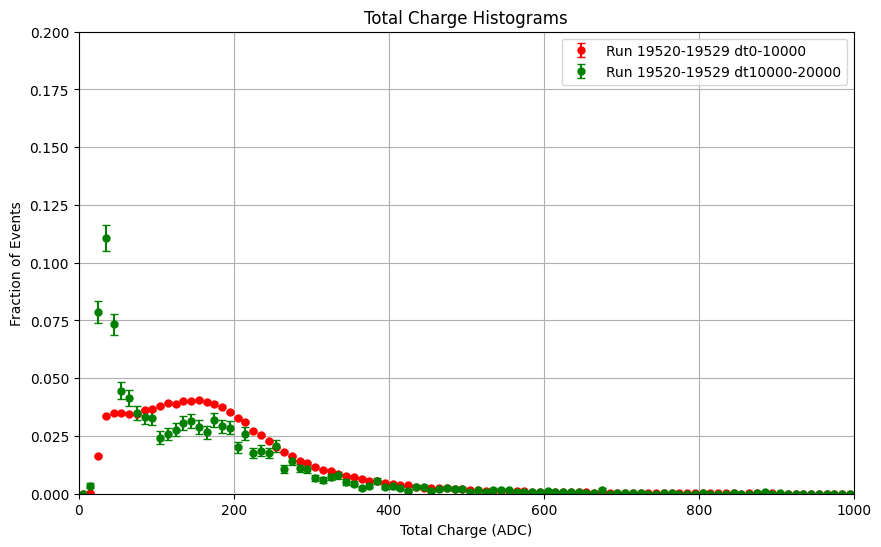

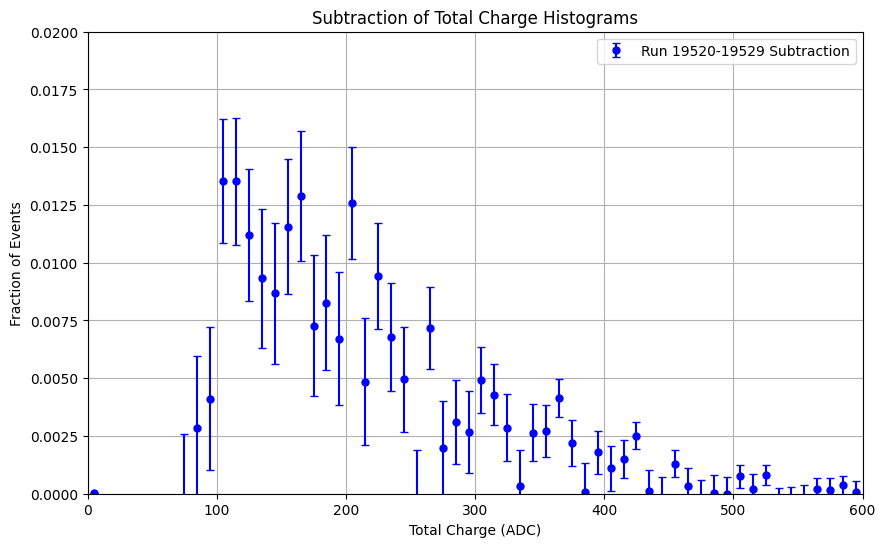

In [4]:
#Normalize the histograms and errors
# Convert to float to avoid casting errors
sum_area1 = sum_area1.astype(float)
sum_area2 = sum_area2.astype(float)
err1 = err1.astype(float)
err2 = err2.astype(float)

# Store original sums for proper error normalization
sum1_orig = np.sum(sum_area1)
sum2_orig = np.sum(sum_area2)

sum_area1 /= sum1_orig
sum_area2 /= sum2_orig
err1 /= sum1_orig  # Scale errors by the same factor as the histogram
err2 /= sum2_orig  # Scale errors by the same factor as the histogram
err_total = np.sqrt(err1**2 + err2**2)
print(err_total)

#plotting hist1 and hist2 on the same plot
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1, yerr=err1, fmt='o', label='Run 19520-19529 dt0-10000', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, sum_area2, yerr=err2, fmt='o', label='Run 19520-19529 dt10000-20000', color='green', markersize=5, capsize=3)
plt.title('Total Charge Histograms')
plt.xlabel('Total Charge (ADC)')
plt.ylabel('Fraction of Events')
plt.ylim(0, 0.2)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('total_charge_histograms.png')
plt.show()

#plotting subtraction hist1 - hist2
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1 - sum_area2, yerr=err_total, fmt='o', label='Run 19520-19529 Subtraction', color='blue', markersize=5, capsize=3)
plt.title('Subtraction of Total Charge Histograms')
plt.xlabel('Total Charge (ADC)')
plt.ylabel('Fraction of Events')
plt.ylim(0, 0.02)
plt.xlim(0, 600)
plt.legend()
plt.grid()
# plt.savefig('subtraction_histograms.png')
plt.show()